# 🍕 EDA — Obesity Multi Classification
### Proyecto Grupal — Multi Clasificación de Obesity

---

## 📖 ¿Qué es un EDA y para qué sirve?

El **Análisis Exploratorio de Datos (EDA)** es el primer paso de todo proyecto de Machine Learning.  
Antes de entrenar cualquier modelo, necesitamos **entender** los datos:
- ¿Qué hay en el dataset?
- ¿Los datos están limpios o tienen errores?
- ¿Qué variables son importantes?
- ¿Hay patrones o relaciones entre variables?

**Analogía:** El EDA es como leer el manual de instrucciones antes de montar un mueble. Puedes saltártelo, pero luego te sobran tornillos.

---

## 🗺️ Hoja de Ruta del Notebook

| Bloque | Qué vamos a hacer |
|--------|-------------------|
| **0** | Importar librerías y cargar datos |
| **1** | Primera inspección del dataset |
| **2** | Análisis de valores nulos |
| **3** | Crear la variable objetivo (target) |
| **4** | Análisis de variables numéricas (sensoriales) |
| **5** | Análisis de variables categóricas (CAEC, CALC) |
| **6** | Correlaciones entre variables |
| **7** | Detección de outliers |
| **8** | Conclusiones y próximos pasos |

---

> ⚠️ **Importante:** Ejecuta las celdas en orden, de arriba a abajo. Cada celda depende de la anterior.

---
## 📦 BLOQUE 0 — Importar librerías y cargar el dataset

**¿Qué son las librerías?**  
Son colecciones de funciones ya escritas por otros que podemos reutilizar.  
- `pandas` → manipular tablas de datos  
- `numpy` → cálculos matemáticos  
- `matplotlib` y `seaborn` → crear gráficos  
- `warnings` → ocultar avisos que no nos interesan

In [19]:
# ─── Cargar de librerías  ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
# ─── Cargar el dataset ────────────────────────────────────────────────────────
# 📌 ACCIÓN: Cambia la ruta al lugar donde tienes guardado el CSV
# La ruta no modificarla. Y poner el mismo nombre todos.
# Los datos se sacan de esta URL https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster
# Hacemos una copia del dataset en la variable df y trabajamos desde ahora con esto

df_read = pd.read_csv('../data/raw/ObesityDataSet.csv')

df = df_read.copy()

print(f'✅ Dataset cargado correctamente')
print(f'📊 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')

✅ Dataset cargado correctamente
📊 Dimensiones: 2111 filas x 17 columnas


---
## 🔍 BLOQUE 1 — Primera inspección del dataset

**Objetivo:** Entender qué hay dentro del dataset sin entrar en detalles todavía.  
Es como abrir una caja y ver qué hay dentro antes de sacar nada.

**Preguntas que vamos a responder:**
- ¿Cuántas filas y columnas tiene?
- ¿Qué significa cada columna?
- ¿Qué tipo de dato tiene cada columna (número, texto, fecha)?

In [5]:
# Ver las primeras 5 filas del dataset (head)
# Esto nos da una idea visual de cómo están organizados los datos
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [6]:
# Información general del dataset
# 'object' = texto | 'float64/int64' = número
print('ℹ️ Información del dataset:')
df.info()

ℹ️ Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF              

In [7]:
# Estadísticas descriptivas de las columnas numéricas (describe)
# count=cuántos valores hay | mean=promedio | std=dispersión | min/max=extremos
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [8]:
# Ver todas las columnas, las object también
df.describe(include='object')

C:\Users\user\AppData\Local\Temp\ipykernel_12272\3638695153.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


In [9]:
# Ver el nombre de todas las columnas disponibles
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

---
## 🕳️ BLOQUE 2 — Análisis de valores nulos

**¿Qué es un valor nulo?**  
Un valor nulo (NaN = Not a Number) es una celda vacía en nuestros datos.  
Ocurre cuando la información no estaba disponible o no se registró.

**¿Por qué importa?**  
Los modelos de ML no pueden trabajar con valores vacíos. Tenemos que decidir qué hacer con ellos:  
- **Eliminar** la fila o columna  
- **Rellenar** con un valor (media, mediana, moda)

**Regla general:**  
- Si una columna tiene `> 40% nulos` → considerar eliminarla  
- Si tiene `< 40% nulos` → rellenar (imputar)

In [10]:
# Contar valores nulos por columna
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

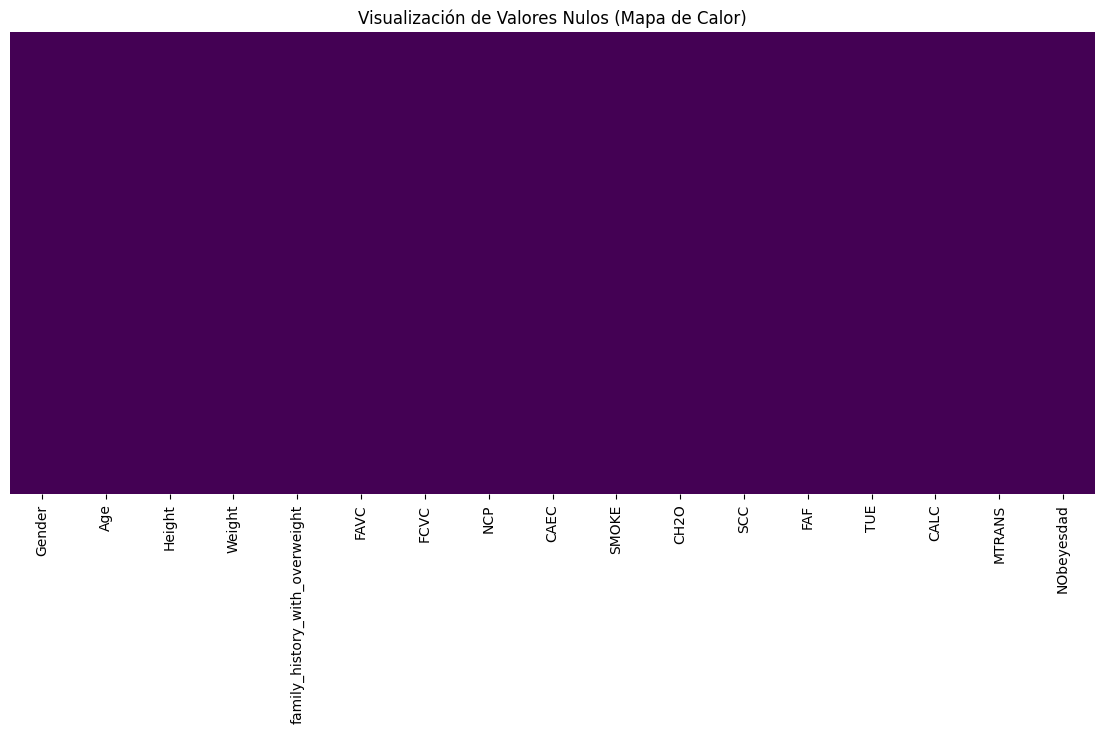

In [ ]:
# Visualizar los nulos con un heatmap (Solo si lo ven necesario)

# 2. Configurar el tamaño de la figura (opcional pero recomendado)
plt.figure(figsize=(14, 6))

# 3. Crear el heatmap
# df.isnull() devuelve True donde hay nulos y False donde no
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# 4. Mostrar el gráfico
plt.title("Visualización de Valores Nulos (Mapa de Calor)")
plt.show()

In [14]:
# Ver como estan distribuidos los datos por SMOKE
df['SMOKE'].value_counts()

SMOKE
no     2067
yes      44
Name: count, dtype: int64

##### SMOKE es un valor muy desbalanceado por lo tanto es un candidato a borrarse

In [18]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

In [ ]:
# ─── DECISIÓN: Qué columnas eliminar ─────────────────────────────────────────
# Estas columnas son metadata (identificadores, nombres) que no aportan al modelo
# 📌 ACCIÓN: Revisa la lista de columnas y ajusta eliminando lo que consideres
#df = df.drop(['In-Country Partner', 'Moisture Percentage', 'Overall'], axis=1)

#### De momento se considera No borrar ninguna columna ya que todas tienen todos los valores y no hay ningún valor nulo.

---
## 🎯 BLOQUE 3 — Observar la variable objetivo (TARGET)

**¿Qué es el target?**  
Es la variable que queremos predecir. En nuestro caso, tipo de Obesidad que está en la columna **NObeyesdad**.

##### Visualizar la distribución del target

In [ ]:
# Visualizar la distribución del target
# Si hay muchas más muestras de una clase que de otra = dataset DESBALANCEADO
# Un dataset desbalanceado puede engañar al modelo

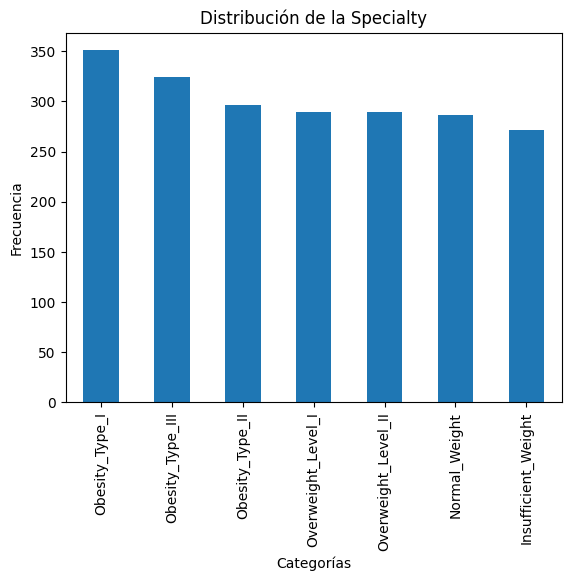

In [15]:
# Contar valores y graficar
df['NObeyesdad'].value_counts().plot(kind='bar')
plt.title('Distribución de la Specialty')
plt.ylabel('Frecuencia')
plt.xlabel('Categorías')
plt.show()

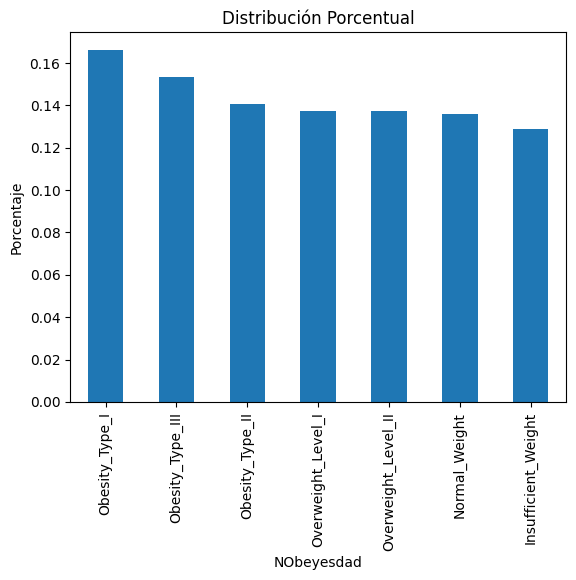

In [17]:
# Visualizar el tanto por ciento del target
df['NObeyesdad'].value_counts(normalize=True).plot(kind='bar')
plt.title('Distribución Porcentual')
plt.ylabel('Porcentaje')
plt.show()

In [18]:
# Ver cuantos registros tiene cada tipo de Obesidad
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

#### Vemos que tenemos 7 valores diferentes y que cada uno tiene más o menos el mismo número de registros, por lo cual, está correcto.

---
## 📊 BLOQUE 4 — Análisis de variables numéricas (sensoriales)

**Objetivo:** Entender cómo se distribuyen las variables sensoriales y si hay diferencias entre los diferentes valores de NObeyesdad.

**¿Qué vamos a ver?**
- **Histograma:** Distribución de cada variable ¿es normal? ¿está sesgada?
- **Boxplot:** Comparación entre categorías de calidad
- **Violinplot:** Distribución completa por categoría

In [ ]:
# Definir las columnas sensoriales que vamos a analizar (Las variables que tenemos en Kaggel que influyen a nuestro modelo)

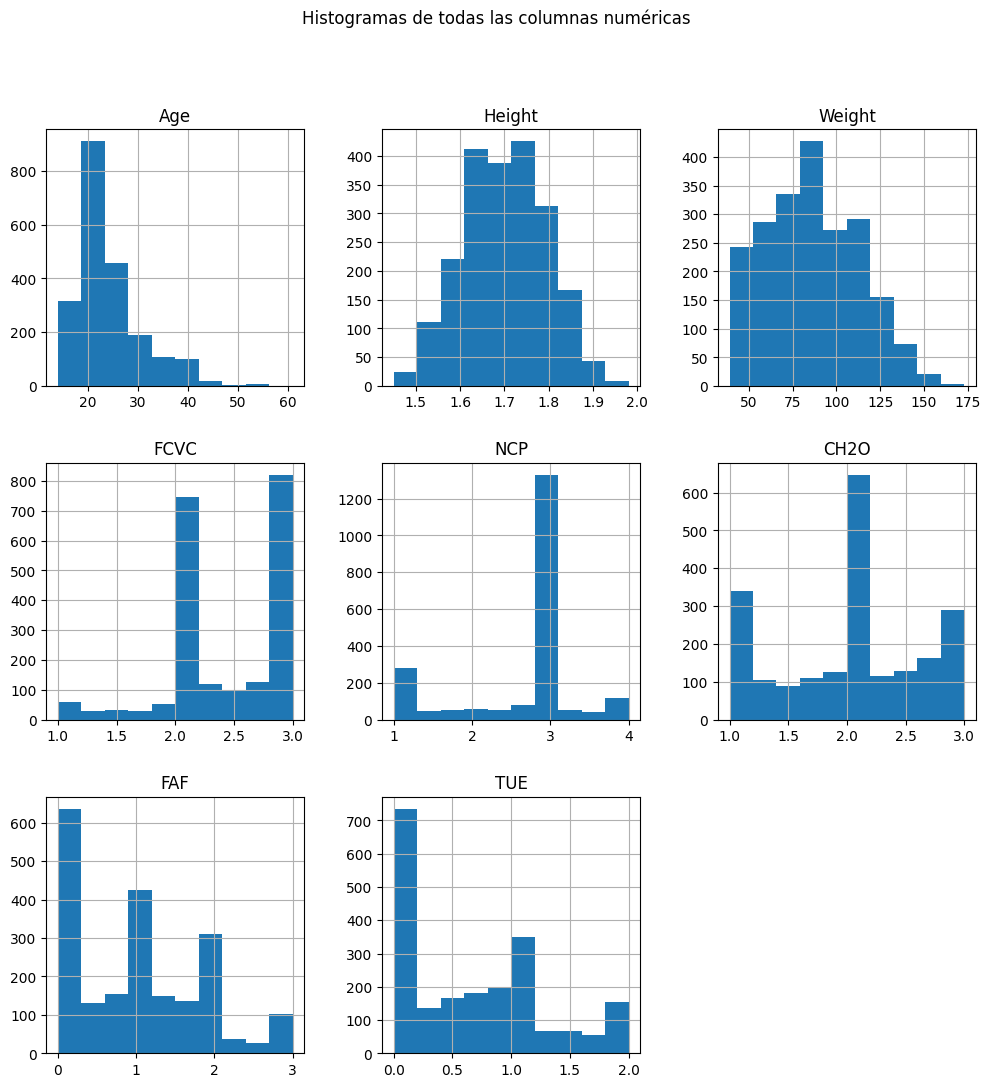

In [16]:
# ─── HISTOGRAMAS ──────────────────────────────────────────────────────────────
# Un histograma muestra cuántas muestras hay en cada rango de valores
# Ideal: distribución en forma de campana (normal)
# Si está muy sesgada hacia un lado, puede indicar outliers

# Crea un histograma para cada columna numérica del DataFrame
df.hist(bins=10, figsize=(12, 12))
plt.suptitle('Histogramas de todas las columnas numéricas')
plt.show()

##### Segmentación Física (Edad y Peso)

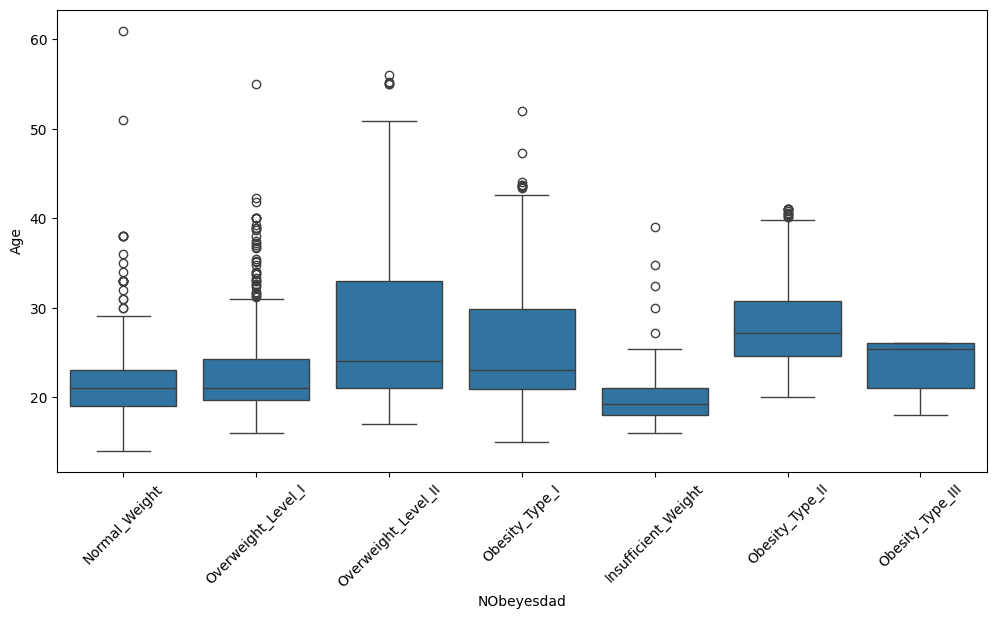

In [ ]:
# Misión: ¿Cómo se distribuyen la Edad y el Peso a través de los niveles de obesidad? ¿Hay solapamiento entre las clases?

# Distribución de la Edad

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el boxplot
sns.boxplot(x='NObeyesdad', y='Age', data=df)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

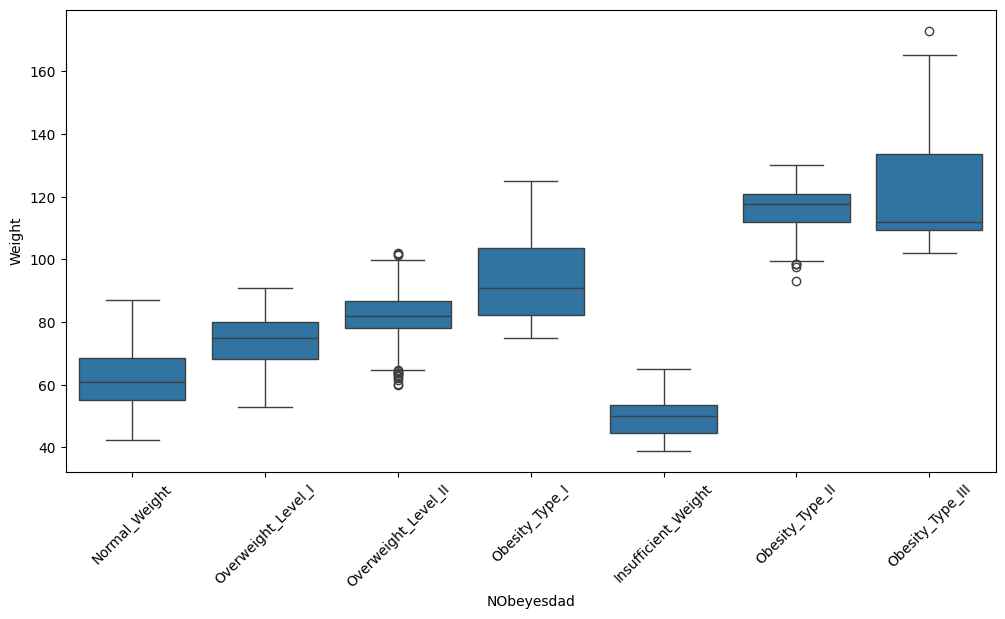

In [ ]:
# Distribución del Peso

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el boxplot
sns.boxplot(x='NObeyesdad', y='Weight', data=df)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

##### Relación Estilo de Vida y Consumo

In [ ]:
# Relación Estilo de Vida y Consumo:
# Misión: ¿Cómo afectan la actividad física (FAF) y el consumo de agua (CH2O) al nivel de obesidad?

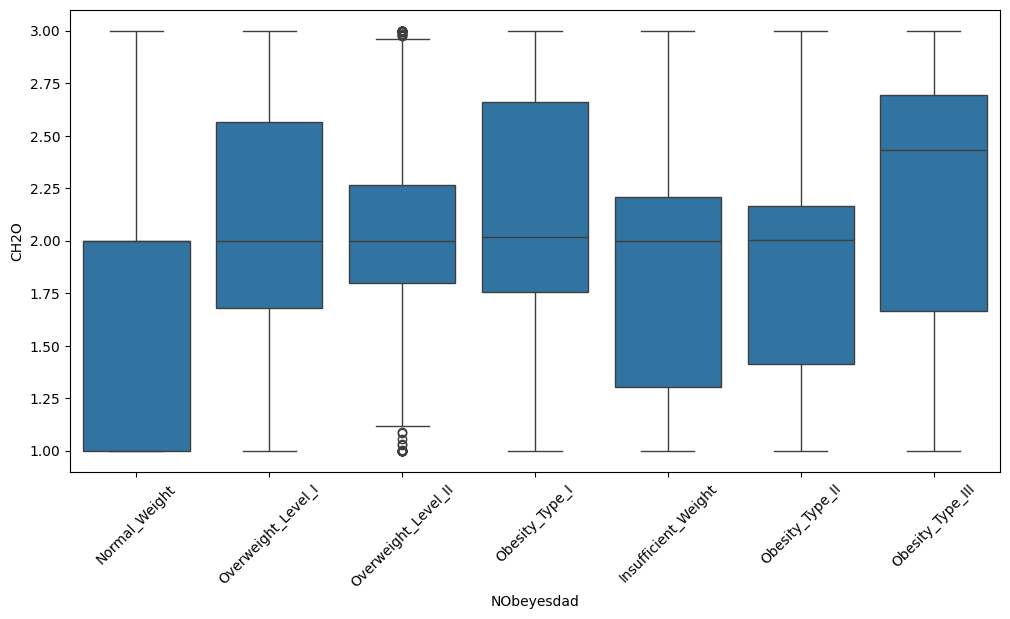

In [ ]:
# Consumo de agua (CH2O)

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el boxplot
sns.boxplot(x='NObeyesdad', y='CH2O', data=df)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

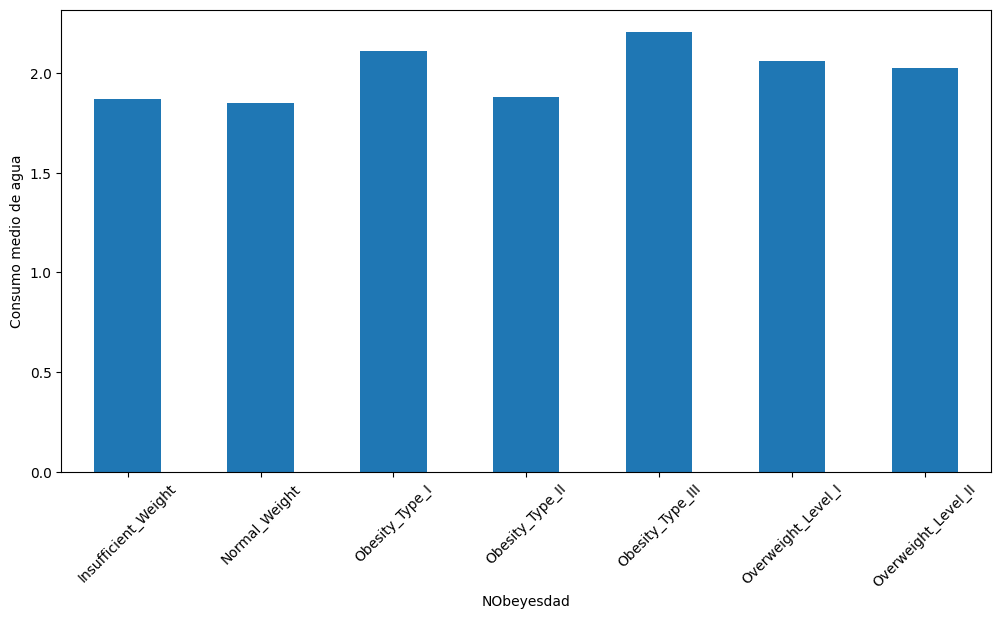

In [ ]:
# Consumo de agua (CH2O)

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el plot
df.groupby('NObeyesdad')['CH2O'].mean().plot(kind='bar')
plt.ylabel('Consumo medio de agua')

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

##### El consumo de agua debería ayudar a controlar la obesidad. Correlación negativa.

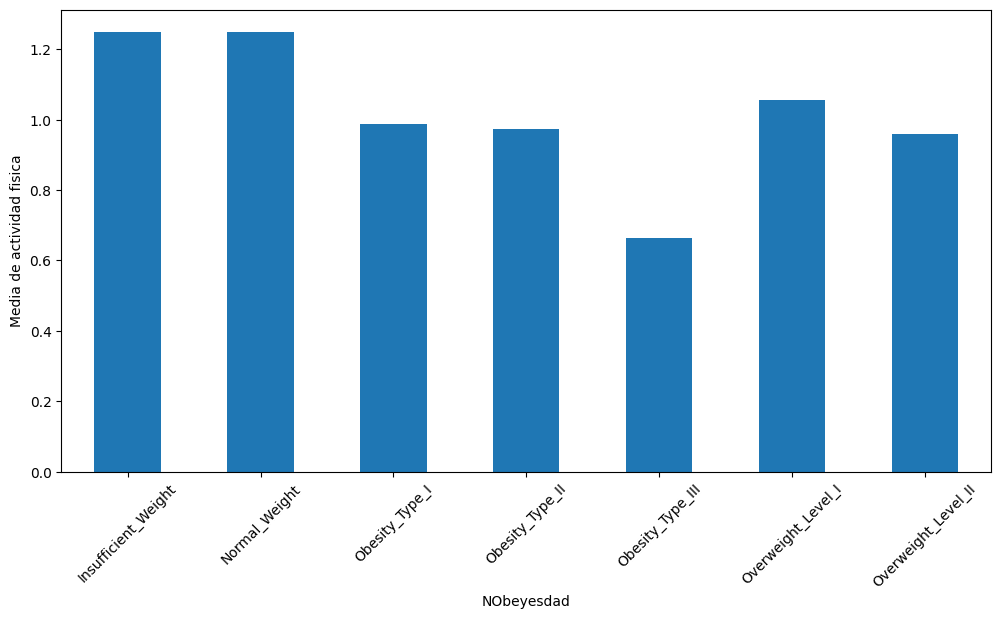

In [ ]:
# Actividad Física (FAF)

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el plot
df.groupby('NObeyesdad')['FAF'].mean().plot(kind='bar')
plt.ylabel('Media de actividad fisica')

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

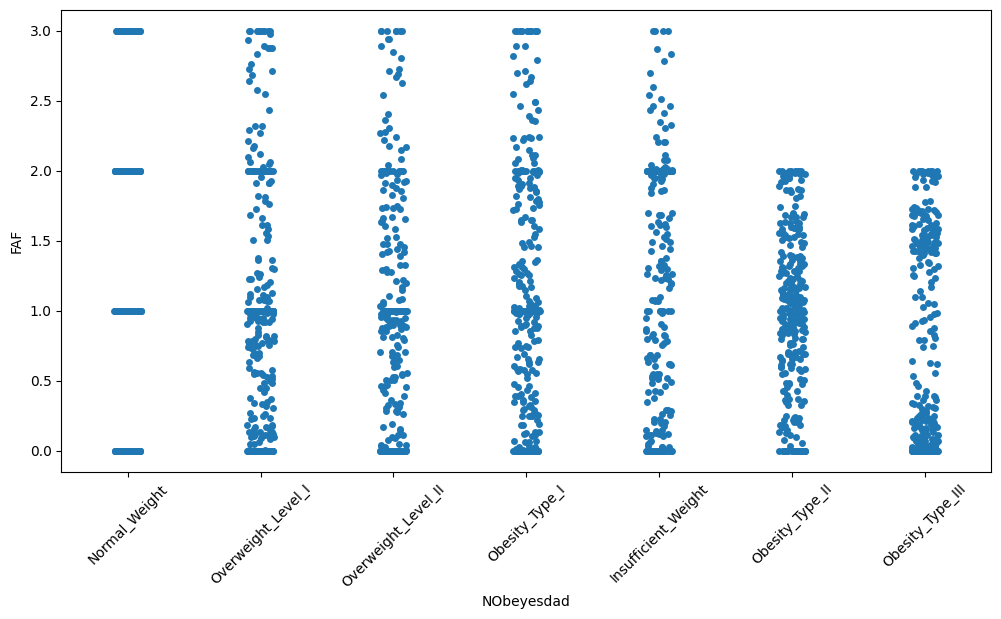

In [ ]:
# Actividad Física (FAF)

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el plot
sns.stripplot(x='NObeyesdad', y='FAF', data=df, jitter=True)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

##### La actividad física (FAF) debería ayudar a controlar la obesidad. Correlación negativa.

---
## 🌍 BLOQUE 5 — Análisis de variables categóricas

**Variables categóricas:** Son las que tienen texto, como Gender, family_history_width_overweight o MTRANS.

##### Impacto del Entorno Familiar

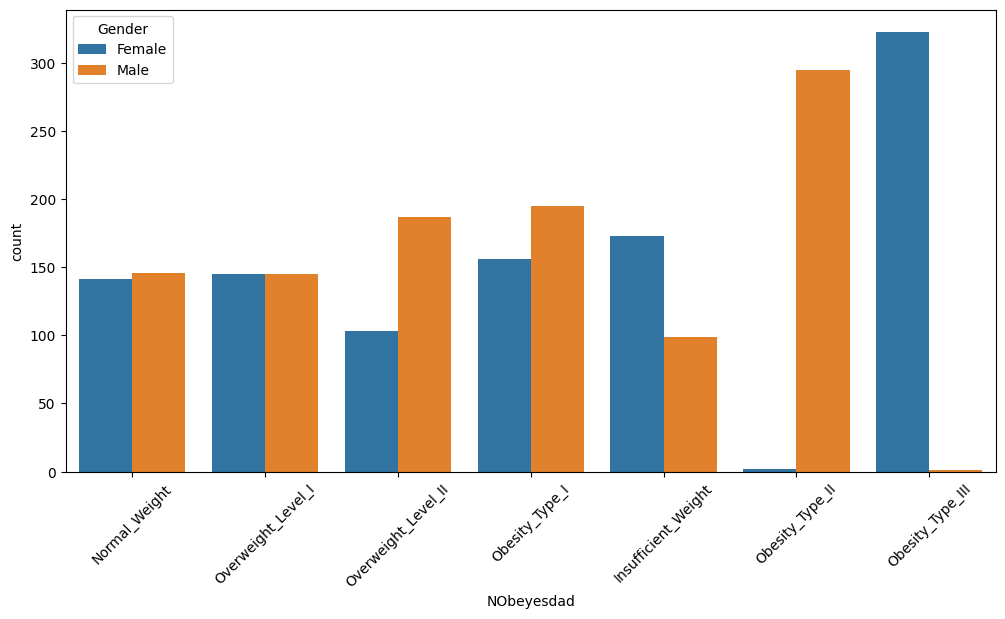

In [ ]:
# Misión: ¿Es el género (Gender) un factor determinante para las clases de Obesidad?

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el countplot
sns.countplot(x='NObeyesdad', hue='Gender', data=df)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

##### La obesidad es más común en mujeres que en hombres por lo tanto los datos arriba expuestos en obesidad tipo 2 y tipo 3 son contrarios y no nos aportan información clara.

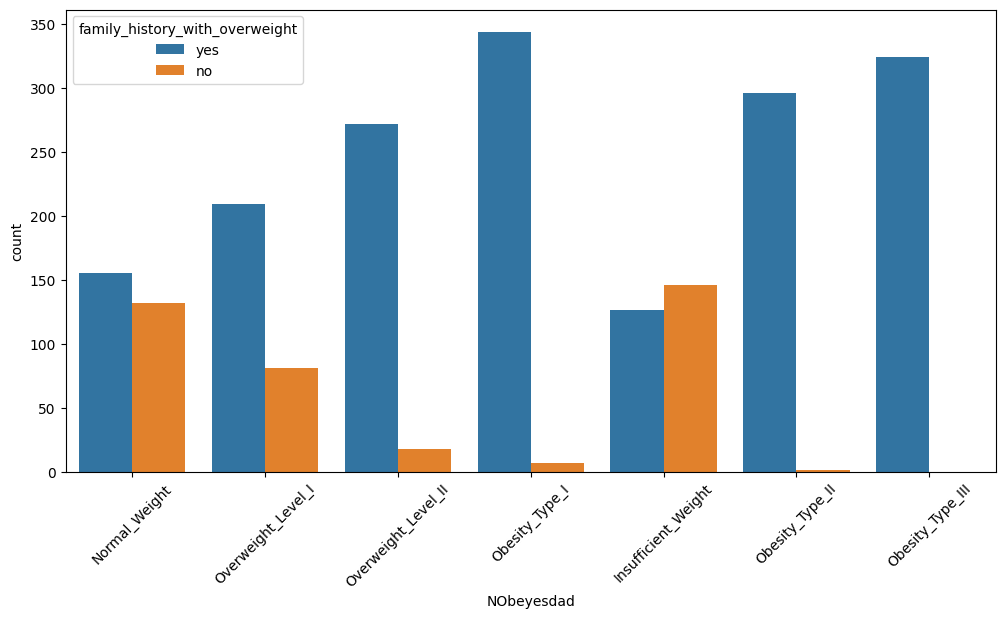

In [ ]:
# Misión: ¿Es el antecedente familiar (family_history_with_overweight) un factor determinante para las clases de Obesidad?

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6))

# 2. Crear el countplot
sns.countplot(x='NObeyesdad', hue='family_history_with_overweight', data=df)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

##### El antecedente familiar definitivamente influye en la Obesidad.

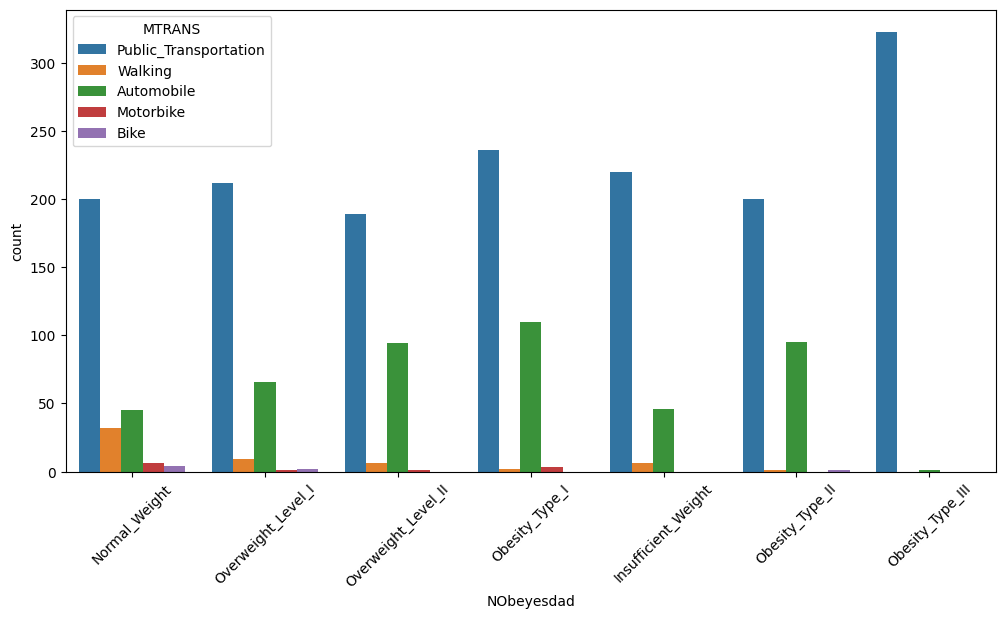

In [52]:
# Misión: ¿Es el medio de transporte (MTRANS) un factor determinante para las clases de Obesidad?

# 1. Configurar el tamaño de la figura (ancho, alto) en pulgadas
plt.figure(figsize=(12, 6)) # Aumenta a 12x6 pulgadas o el tamaño que desees

# 2. Crear el countplot
sns.countplot(x='NObeyesdad', hue='MTRANS', data=df)

# 3. Opcional: Rotar etiquetas del eje X si son muy largas
plt.xticks(rotation=45)

# 4. Mostrar el gráfico
plt.show()

In [53]:
df['MTRANS'].value_counts()

MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

##### El transporte público tiene muchos más registros que los demás porque es el más común de los medios de transporte en Colombia, México y Perú. No tengo claro que pueda aportar mucho.

---
## 🔥 BLOQUE 6 — Matriz de correlación

**¿Qué es la correlación?**  
Mide cuánto se relacionan dos variables numéricas entre sí.  
- Correlación `+1` → cuando una sube, la otra también sube (relación perfecta positiva)  
- Correlación `-1` → cuando una sube, la otra baja (relación perfecta negativa)  
- Correlación `0` → no hay relación

**¿Para qué sirve en ML?**
- Identificar qué variables tienen más relación con el target
- Detectar variables muy correlacionadas entre sí (redundantes) — puede ser mejor eliminar una

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [56]:
df['NObeyesdad'].unique()

<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

In [ ]:
# ─── HEATMAP DE CORRELACIÓN ───────────────────────────────────────────────────
# Solo calculamos correlación entre columnas numéricas

# Seleccionar solo las columnas numéricas
#df_correlacion = df.select_dtypes(include=['float64', 'int64'])
df_correlacion = df[['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'NObeyesdad']]

# Mapear valores: Normal_Weight=0, Overweight_Level_I=1, Overweight_Level_II=2, Obesity_Type_I=3, Insufficient_Weight=4, 
#                 Obesity_Type_II=5, Obesity_Type_III=6
# Definir el mapeo de múltiples valores
mapeo = {'Normal_Weight': 0, 'Overweight_Level_I': 1, 'Overweight_Level_II': 2, 'Obesity_Type_I': 3, 'Insufficient_Weight': 4,
         'Obesity_Type_II': 5, 'Obesity_Type_III': 6}

df_correlacion['NObeyesdad'] = df_correlacion['NObeyesdad'].map(mapeo)

matriz_corr = df_correlacion.corr()

In [63]:
df_correlacion.sample(10)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad
267,38.000000,1.700000,78.000000,3.000000,3.000000,2.000000,0.000000,0.000000,2
2057,26.000000,1.632983,111.157811,3.000000,3.000000,2.638896,0.000000,0.224559,6
1994,21.282238,1.748951,133.662583,3.000000,3.000000,2.247979,1.609938,0.849236,6
797,18.026457,1.752123,80.000000,2.000000,2.794156,2.377362,0.101236,0.105895,1
905,20.310940,1.849425,85.228116,2.146598,3.000000,2.100112,1.171160,0.833761,1
1738,26.348156,1.830317,117.757010,2.068834,3.000000,2.543841,1.217993,0.038253,5
414,33.000000,1.830000,113.000000,2.000000,1.000000,2.000000,1.000000,2.000000,3
1534,20.013906,1.647821,106.509947,2.869778,1.468948,1.656082,0.000000,1.444033,5
294,18.000000,1.860000,110.000000,2.000000,1.000000,2.000000,1.000000,2.000000,3
662,20.552695,1.523426,42.000000,3.000000,1.000000,1.185062,0.000000,0.076654,4


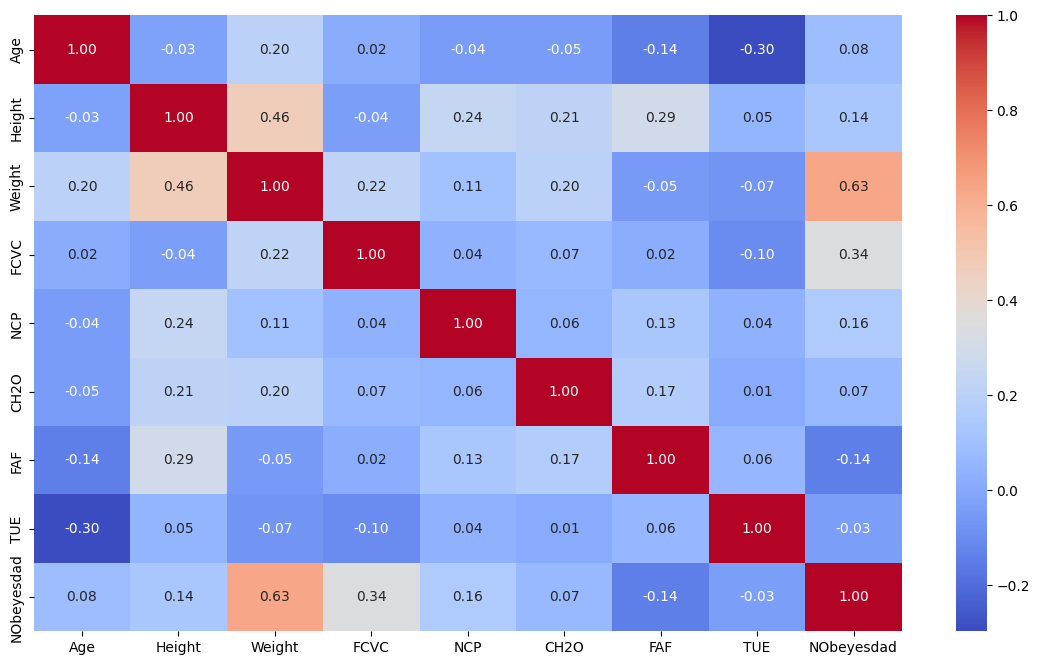

In [59]:
# 3. Pintar la matriz con Seaborn
plt.figure(figsize=(14, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [ ]:
# Cambiar a 1 y 0
df['FAVC'].value_counts()

FAVC
yes    1866
no      245
Name: count, dtype: int64

In [ ]:
# Cambiar a 1, 0.75, 0.5 y 0
df['CAEC'].value_counts()

CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

In [ ]:
# Cambiar a 0.5, 0, 0.75 y 1
df['CALC'].value_counts()

CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

In [ ]:
# Cambiar a 0 y 1
df['SCC'].value_counts()

SCC
no     2015
yes      96
Name: count, dtype: int64

In [66]:
# Cambiar a 1 y 0
df['family_history_with_overweight'].value_counts()

family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64

---
## 🎯 BLOQUE 7 — Detección de Outliers

**¿Qué es un outlier?**  
Es un valor extremo que está muy alejado del resto.  
Por ejemplo: si todas las personas tienen entre 20 y 61 años y hay uno con 100 años, ese es un outlier.

**¿Por qué importa?**  
Los outliers pueden distorsionar el modelo, haciéndolo aprender de casos excepcionales en lugar de la norma.

**Método IQR:**  
Se considera outlier cualquier valor fuera del rango `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]`

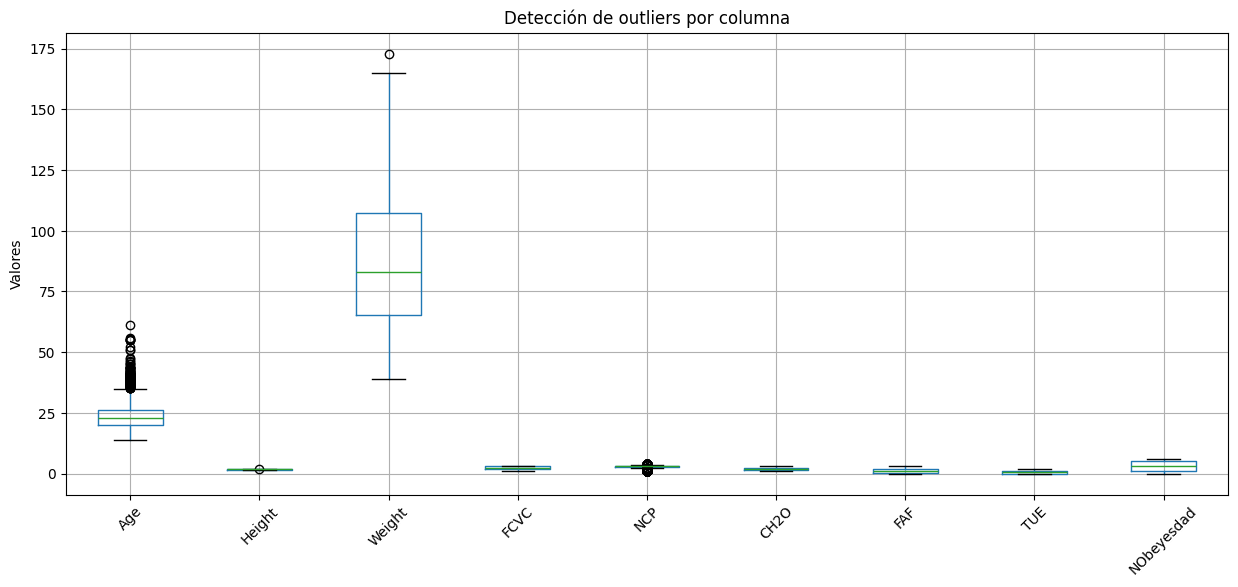

In [67]:
# ─── BOXPLOTS PARA DETECTAR OUTLIERS ─────────────────────────────────────────
# Los puntos fuera de los "bigotes" del boxplot son outliers

# Crear el boxplot
df_correlacion.boxplot(figsize=(15, 6))
plt.title('Detección de outliers por columna')
plt.ylabel('Valores')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# ─── CUANTIFICAR OUTLIERS CON EL MÉTODO IQR ───────────────────────────────────
#Para calcular si es correcto con las formulas vistas en clase (solo si ven outliers)

# Valorar los datos numéricos [Age, Weight]

In [68]:
# Verficar Age

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['Age'] < limite_inferior) | (df['Age'] > limite_superior)]

print("----------------- Age --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- Age --------------------
Cuartil 1 (Q1): 19.947192
Cuartil 3 (Q3): 26.0
IQR: 6.052807999999999
Límite Inferior: 10.867980000000003
Límite Superior: 35.079212
------------------------------
Número de outliers: 168
Valores atípicos:
      Gender        Age    Height      Weight family_history_with_overweight  \
13      Male  41.000000  1.800000   99.000000                             no   
21    Female  52.000000  1.690000   87.000000                            yes   
33      Male  39.000000  1.790000   90.000000                             no   
92      Male  55.000000  1.780000   84.000000                            yes   
104   Female  38.000000  1.560000   80.000000                            yes   
...      ...        ...       ...         ...                            ...   
1740    Male  37.765356  1.763582  117.861590                            yes   
1775    Male  37.207082  1.762921  118.401740                            yes   
1776    Male  38.108940  1.7528

In [69]:
# Verficar Weight

# 1. Calcular cuartiles Q1 y Q3
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)

# 2. Calcular IQR
IQR = Q3 - Q1

# 3. Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# 4. Cuantificar/Filtrar valores atípicos
outliers = df[(df['Weight'] < limite_inferior) | (df['Weight'] > limite_superior)]

print("----------------- Weight --------------------")
print(f"Cuartil 1 (Q1): {Q1}")
print(f"Cuartil 3 (Q3): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite Inferior: {limite_inferior}")
print(f"Límite Superior: {limite_superior}")
print("-" * 30)
print(f"Número de outliers: {len(outliers)}")
print("Valores atípicos:")
print(outliers)

----------------- Weight --------------------
Cuartil 1 (Q1): 65.473343
Cuartil 3 (Q3): 107.430682
IQR: 41.957339000000005
Límite Inferior: 2.537334499999993
Límite Superior: 170.3666905
------------------------------
Número de outliers: 1
Valores atípicos:
    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
344   Male  18.0    1.87   173.0                            yes  yes   3.0   

     NCP        CAEC SMOKE  CH2O SCC  FAF  TUE       CALC  \
344  3.0  Frequently    no   2.0  no  2.0  1.0  Sometimes   

                    MTRANS        NObeyesdad  
344  Public_Transportation  Obesity_Type_III  


---
## ✅ BLOQUE 8 — Conclusiones del EDA y próximos pasos

**Completa esta sección al terminar el análisis. Aquí van las conclusiones.**

Considero que las variables que influyen son: (12)

*Hábitos alimenticios: FAVC, FCVC, NCP, CAEC, CH2O, CALC*

*Atributos condición física: TUE, FAF*

*Demás variables: Age, Height, Weight, family_history_with_overweight*

*Columnas candidatas a ser borradas: SMOKE, MTRANS, SCC y Gender*

En el preprocesamiento decidiré que hacer con estas columnas

In [71]:
df.sample(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
1957,Female,26.000000,1.641209,111.856492,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.153669,Sometimes,Public_Transportation,Obesity_Type_III
346,Female,21.000000,1.540000,47.000000,yes,no,3.000000,3.000000,Always,no,1.000000,no,2.000000,0.000000,no,Public_Transportation,Normal_Weight
963,Female,19.755797,1.542328,63.856193,no,yes,2.628791,2.762883,Sometimes,no,1.512035,yes,0.303722,0.003229,Sometimes,Public_Transportation,Overweight_Level_I
637,Male,18.000000,1.845399,60.000000,yes,yes,3.000000,4.000000,Sometimes,no,2.000000,no,2.000000,0.000000,no,Automobile,Insufficient_Weight
1390,Female,22.676243,1.620938,82.283185,yes,yes,1.967061,1.000000,Sometimes,no,2.548651,no,0.249264,1.516731,Sometimes,Public_Transportation,Obesity_Type_I
505,Female,26.000000,1.629191,104.826776,yes,yes,3.000000,3.000000,Sometimes,no,2.654702,no,0.000000,0.555468,Sometimes,Public_Transportation,Obesity_Type_III
949,Male,23.000000,1.701584,75.093569,yes,yes,3.000000,3.205009,Sometimes,no,2.643468,no,0.998039,1.898139,Sometimes,Public_Transportation,Overweight_Level_I
851,Female,21.012569,1.758628,78.370039,yes,yes,3.000000,1.000000,Sometimes,no,2.000000,no,2.971832,0.000000,Sometimes,Public_Transportation,Overweight_Level_I
1381,Female,33.226808,1.557943,77.647716,yes,yes,2.020910,2.093831,Sometimes,no,1.506518,no,0.000000,0.000000,Sometimes,Automobile,Obesity_Type_I
1689,Male,25.062942,1.828391,120.998266,yes,yes,3.000000,3.000000,Sometimes,no,3.000000,no,1.685369,0.264969,Sometimes,Public_Transportation,Obesity_Type_II


In [72]:
# ─── GUARDAR EL DATASET LIMPIO PARA EL SIGUIENTE NOTEBOOK ────────────────────
# Este CSV limpio será el punto de partida del notebook de preprocesamiento y modelado
# Debe esta en la carpeta processed

import os

# 1. Definir carpeta y nombre de archivo
folder_name = '../data/processed/'
file_name = 'ObesityDataSet_clean_jm.csv'
file_path = os.path.join(folder_name, file_name)

# 2. Guardar el DataFrame
df.to_csv(file_path, index=False, encoding='utf-8')
print(f"Archivo guardado en: {file_path}")

Archivo guardado en: ../data/processed/ObesityDataSet_clean_jm.csv
